In [2]:
# created by Yann Buchholzer and Julius Zimmler
import numpy as np
import matplotlib.pyplot as plt

In [3]:

# Create datasample, calculate radius², pi, sigma and number of points inside the circle

def pi_x(experiments, pairs, dimension):
    
    points = np.random.uniform(low = -1.0, high = 1.0, size = (dimension, pairs, experiments)) # generating the points
    radius_squared = (points**2).sum(axis=0) 
    inside_the_circle = (radius_squared <= 1)
    inside_the_square = ((-1.0 <= points[0]) & (points[0] <= 1.0) & 
                         (-1.0 <= points[1]) & (points[1] <= 1.0))
    pi_by_4 = inside_the_circle.sum(axis=0) / inside_the_square.sum(axis=0)
    pi = 4 * pi_by_4
    sigma = np.sqrt(4*inside_the_circle.sum()/(pairs-1))
    
    return radius_squared, pi,sigma, inside_the_circle

## 1.1 Just do one big experiment

In [5]:
# Experimental setup

experiments = 1
dimension = 2
pairs = 10000

# calculate radius², pi, sigma and number of points inside the circle (indicator variable)

radius_sq, pi_1, sigma, inside_the_circle = pi_x(experiments,pairs,dimension)

print("The mean of this experiment is",pi_1.mean(), "while the standard derivation is",
sigma) # From sheet should be 1.6, but we have only one experiment, so pi_x = final answer => uncertainty =0?



The mean of this experiment is 3.1568 while the standard derivation is 1.7768274287536079


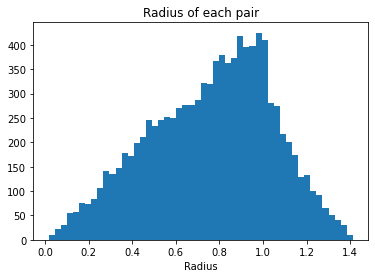

In [6]:
# Histogramm of radius

plt.hist(np.sqrt(radius_sq), bins = 50)
plt.title("Radius of each pair")
plt.xlabel("Radius")
plt.show()


Explanation: We are looking at the radius $r= \sqrt{x^2+y^2}$ with $x,y \in [0,1]$ randomly distributed. 

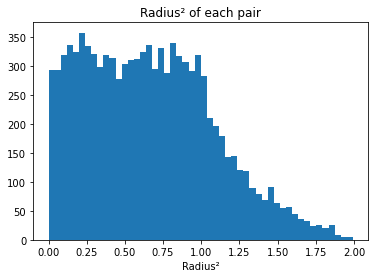

In [7]:
# Histogramm of radius²

plt.hist(radius_sq, bins = 50)
plt.title("Radius² of each pair")
plt.xlabel("Radius²")
plt.show()

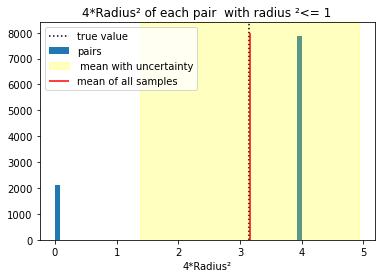

In [14]:
# histogram of the indicator variable
plt.hist(4*inside_the_circle , bins =50, label = "pairs")
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_1.mean() - sigma, pi_1.mean() + sigma, alpha=0.25, color = "yellow" ,label= " mean with uncertainty"  )
plt.vlines(pi_1.mean(),0,8000, color='red', label = "mean of all samples")
plt.title("4*Radius² of each pair  with radius ²<= 1")
plt.xlabel("4*Radius²")
plt.legend()
plt.show()

## 1.2 Split into 100 experiments

In [15]:
# New experimental setup

experiments = 100
dimension = 2
pairs = 100

# Calculated pi 

pi_2 = pi_x(experiments,pairs,dimension)[1]

print("Estimate π_x for each experiment:\n", pi_2)
print("The mean of this experiment is", pi_2.mean(), "while the standard derivation is",
pi_2.std())


Estimate π_x for each experiment:
 [2.8  3.36 3.48 3.36 3.   3.2  3.2  3.08 3.24 3.24 3.24 3.2  3.4  2.92
 3.08 3.12 3.2  3.04 3.48 3.16 3.   3.28 2.92 3.08 3.12 3.08 3.44 3.
 3.2  3.24 3.32 3.44 3.12 3.56 3.08 3.12 3.24 3.08 3.08 3.08 3.44 3.36
 3.08 3.12 3.08 3.08 3.32 3.24 2.96 3.2  3.   3.   3.08 3.4  3.2  3.16
 2.88 3.2  3.   3.36 3.28 2.92 3.08 3.24 2.88 3.12 2.8  2.96 2.96 2.84
 3.04 3.28 2.96 3.44 3.12 3.2  2.92 3.24 3.12 3.44 3.28 3.2  3.04 3.08
 3.08 3.24 3.16 3.   3.36 3.28 2.76 3.16 3.2  3.   3.24 3.36 3.28 2.8
 2.84 3.08]
The mean of this experiment is 3.1471999999999998 while the standard derivation is 0.17259246797007105


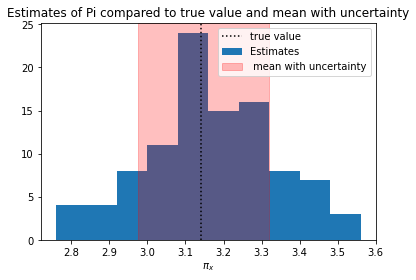

In [16]:
# Plot a histogram of the estimates
plt.hist(pi_2, label = "Estimates")
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_2.mean() - pi_2.std(), pi_2.mean() + pi_2.std(), alpha=0.25, color = "red", 
            label = " mean with uncertainty"  )
plt.title("Estimates of Pi compared to true value and mean with uncertainty")
plt.xlabel("$π_x$")
plt.legend()
plt.show()

## 1.3 A Zillion Little Experiments

C:\Users\Win10\AppData\Local\Temp/ipykernel_9428/2256627837.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  sigma = np.sqrt(4*inside_the_circle.sum()/(pairs-1))


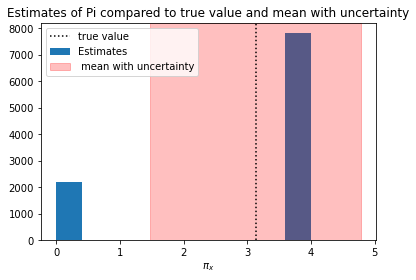

In [18]:
# New experimental setup

experiments = 10000
dimension = 2
pairs = 1

# Calculated pi 

pi_3 = pi_x(experiments,pairs,dimension)[1]

# Histogramm of Estimates
plt.hist(pi_3, label = "Estimates")
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_3.mean() - pi_3.std(), pi_3.mean() + pi_3.std(), alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
plt.title("Estimates of Pi compared to true value and mean with uncertainty")
plt.xlabel("$π_x$")
plt.legend()
plt.show()

### Explanation:

We have 2 different cases: Either the pair is inside the circle or it is not inside the circle. If it is inside the circle we get $4\cdot1$ as result. If it is not we get 0, since we look for inside_the_circle.sum(axis=0) / inside_the_square.sum(axis=0) = inside_the_circle/ inside_the_square.

## 1.4 Stop and think

In [20]:
# Different results: Mean with uncertainty

print(pi_1.mean(),'+-',sigma)
print(pi_2.mean(),'+-',pi_2.std())
print(pi_3.mean(),'+-',pi_3.std())
print(np.pi)

3.1568 +- 1.7768274287536079
3.1471999999999998 +- 0.17259246797007105
3.126 +- 1.6529137908554097
3.141592653589793


All computational results are close to the true result of pi. The difference between these methods lies in different uncertainties. 

The standard deviation of a single experiment doesn't make much sense, since the final answer and $\pi_x$ are everytime exactly the same, therefore you would get always an uncertainty of 0, which is not the case.



## 1.5 More Experiments vs. Longer Experiments

In [21]:
# Combination of pairs
pairs = np.array([10,100,1000,10000])
experiments = np.array([10,100,1000,10000])
X_P = [] 

# Store the results
pi_mean = np.zeros(16) #result of (X,P) experiment  
pi_all = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]] # result of all pairs divided by combination (X,P)
pi_std = np.zeros(16)

for a in range(len(pairs)):
    for c in range(len(experiments)):
        pi_mean[c*4+a] = pi_x(experiments[c],pairs[a],2)[1].mean()    # Final result of experiment (X,P)
        pi_std[c*4+a] = pi_x(experiments[c],pairs[a],2)[1].std()      # Uncertainty of experiment (X,P)
        pi_all[c*4+a] = pi_x(experiments[c],pairs[a],2)[1] # all calculated pi_x
        X_P = np.append(X_P,(experiments[c],pairs[a]))                # List of used combination
        
pi_tot_std = np.sqrt(1/15*np.sum((pi_mean-pi_mean.mean())**2)) 
        
print("The final estimate of pi from all the experiments is",pi_mean.mean(),"+-",pi_tot_std)


The final estimate of pi from all the experiments is 3.12424738 +- 0.05633641697126772


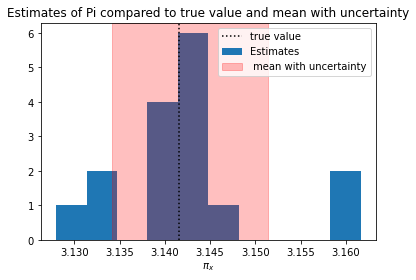

In [26]:
# Nicht gebraucht??
plt.hist(pi_mean, label = "Estimates")
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_mean.mean() - pi_tot_std, pi_mean.mean()+ pi_tot_std, alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
plt.title("Estimates of final Pi from all experiments compared to true value and mean with uncertainty of all experiments")
plt.xlabel("$π_x$")
plt.legend()
plt.show()

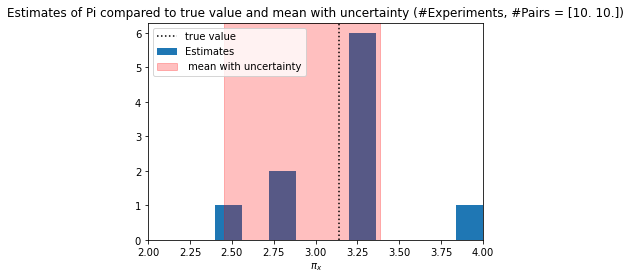

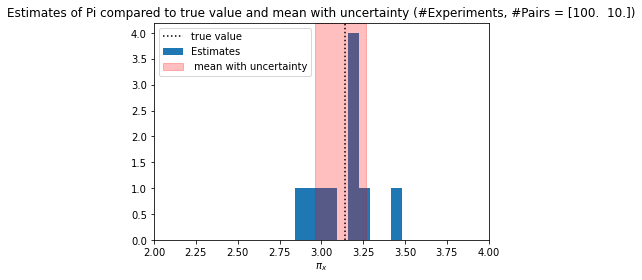

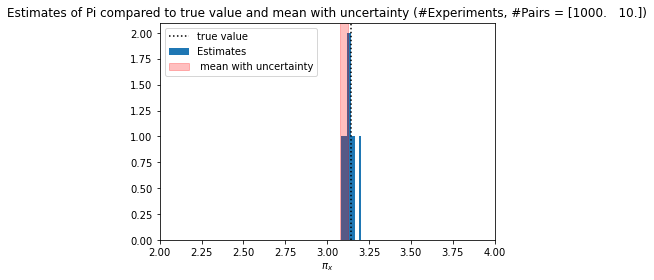

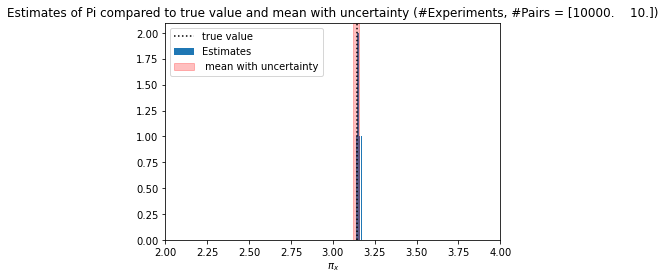

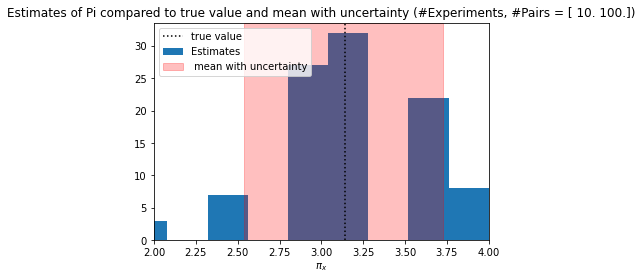

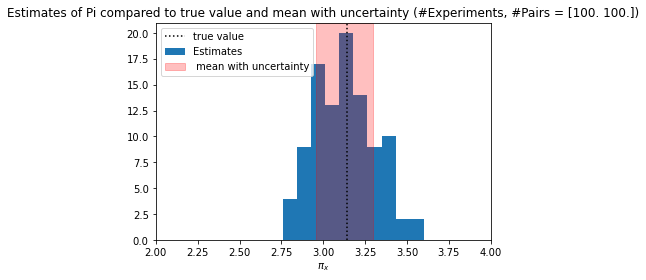

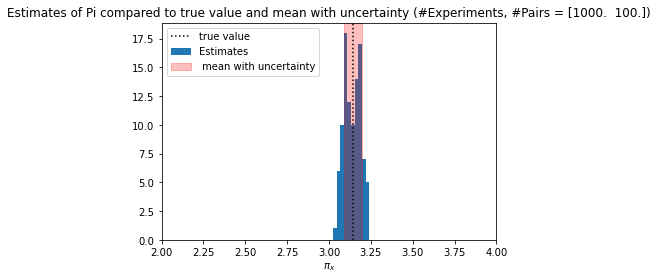

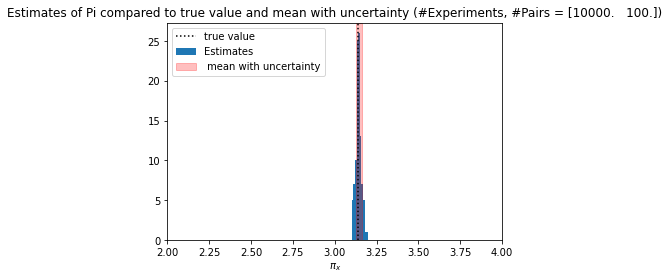

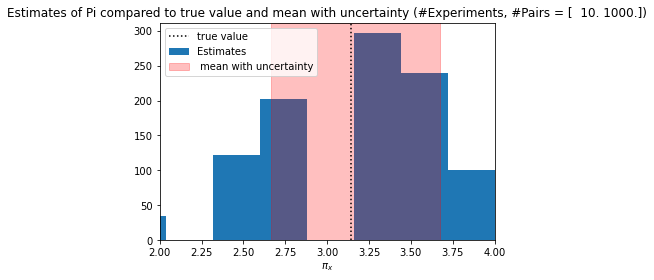

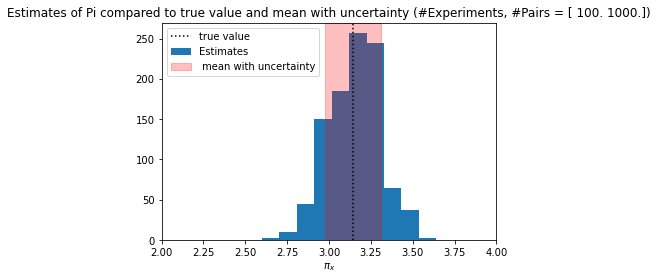

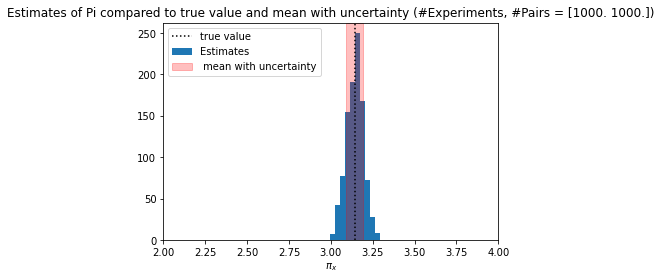

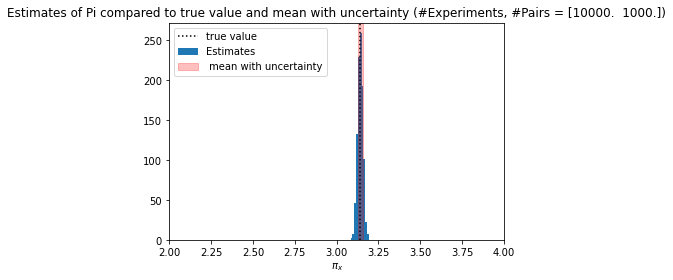

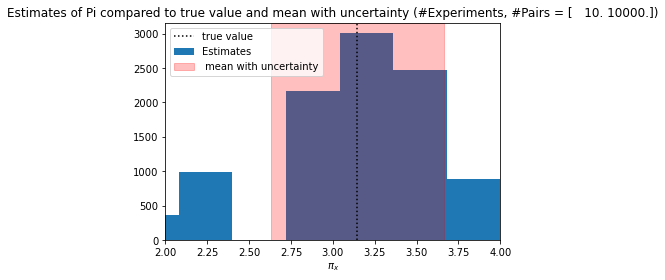

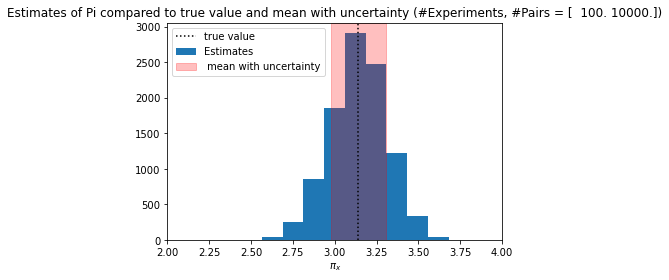

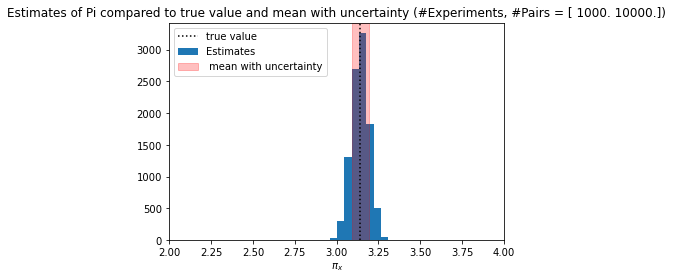

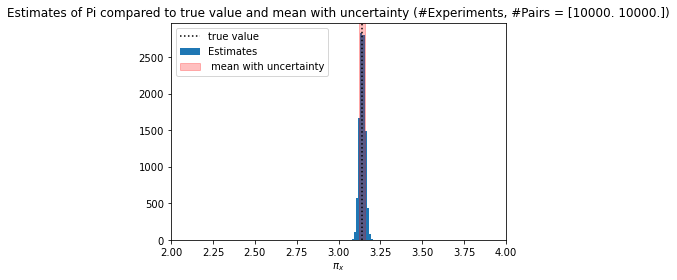

In [27]:
# Repartition of experiment
X_P = X_P.reshape(16,2)

# 16 histogramm  with same limits on x-axis
for x in range(0,16):
    plt.hist(pi_all[x], label = "Estimates", bins = 10)
    plt.axvline(np.pi, color='black', zorder = 1, linestyle = ':', label = "true value")
    plt.axvspan(pi_mean[x] - pi_std[x], pi_mean[x] + pi_std[x], alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
    plt.title(f"Estimates of Pi compared to true value and mean with uncertainty (#Experiments, #Pairs = {X_P[x]})")
    plt.xlabel("$π_x$")
    plt.xlim(2,4)
    plt.legend()
    plt.show()

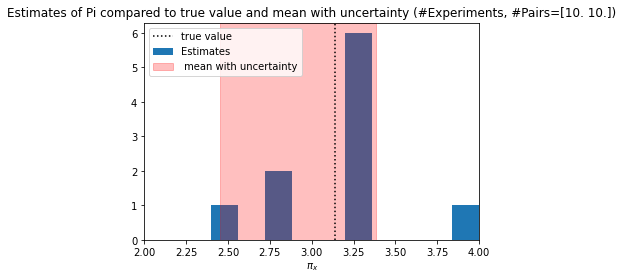

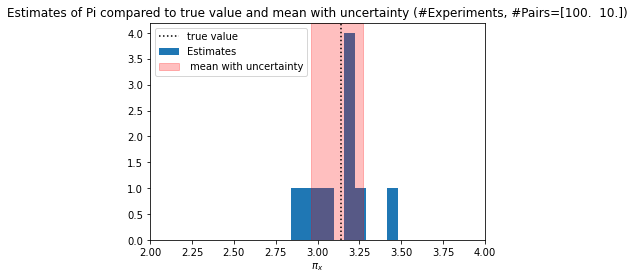

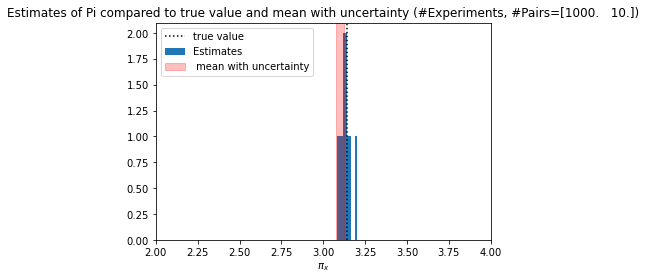

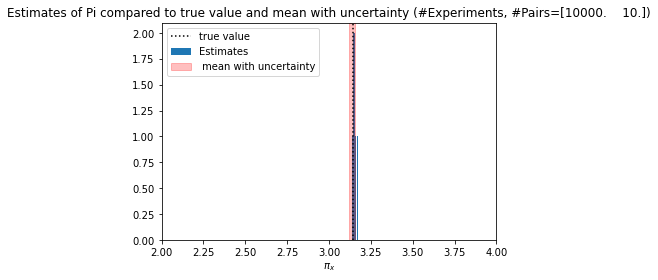

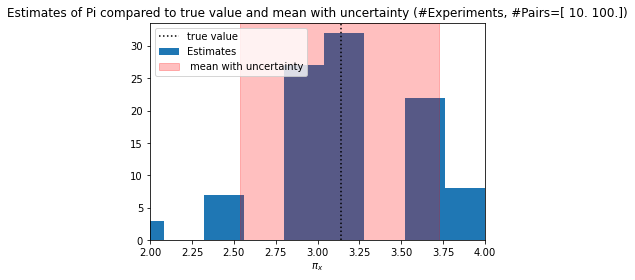

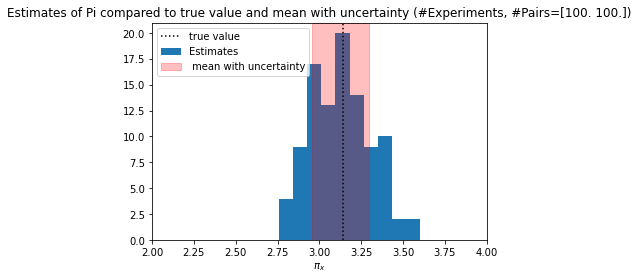

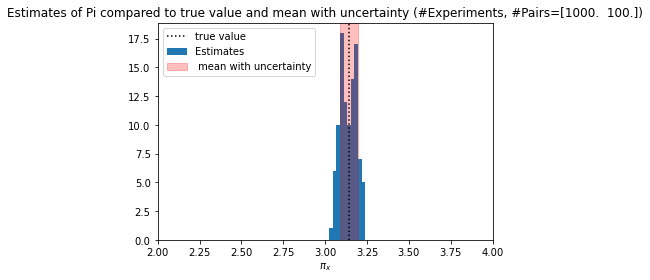

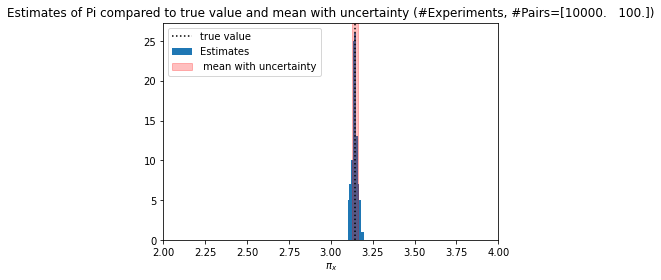

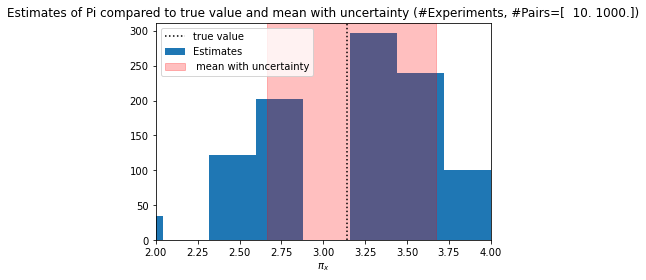

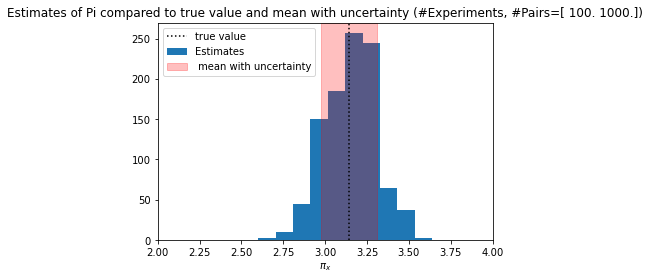

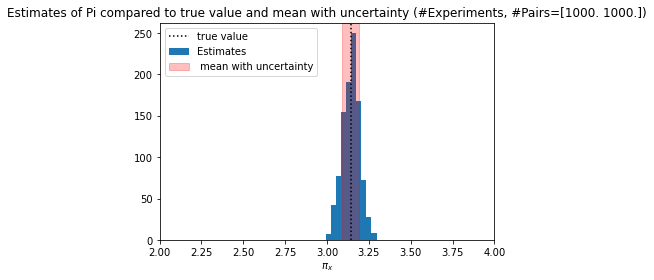

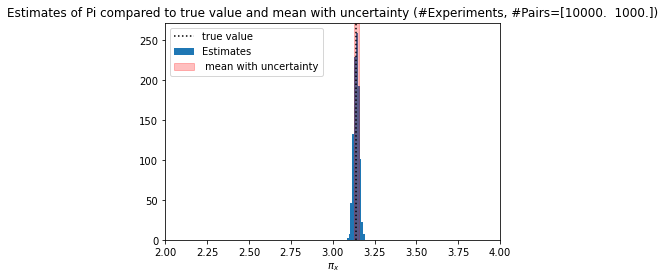

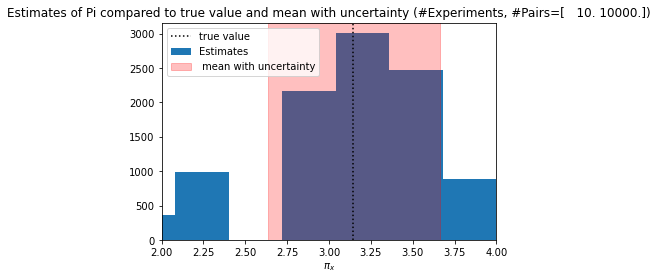

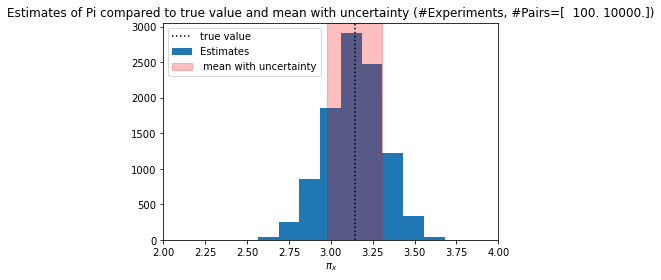

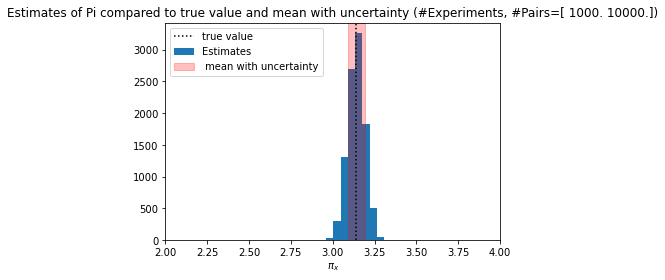

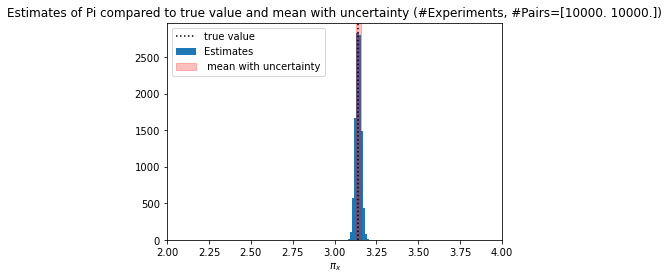

In [29]:
# 16 histogramm  without same limits on x-axis
for x in range(0,16):
    plt.hist(pi_all[x], label = "Estimates", bins = 10)
    plt.axvline(np.pi, color='black', zorder = 1, linestyle = ':', label = "true value")
    plt.axvspan(pi_mean[x] - pi_std[x], pi_mean[x] + pi_std[x], alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
    plt.title(f"Estimates of Pi compared to true value and mean with uncertainty (#Experiments, #Pairs={X_P[x]})")
    plt.xlabel("$π_x$")
    plt.xlim(2,4)
    plt.legend()
    plt.show()

In [35]:

# seperate the 16 results by fixed pairs
pi_std_fixed_pairs = pi_std.reshape(4,4)

# seperate the 16 results by fixed experiments
pi_std_fixed_experiments = pi_std_fixed_pairs.T

You should have the same number of pairs and experiment to minimize the uncertainty, if you have a fix X*P

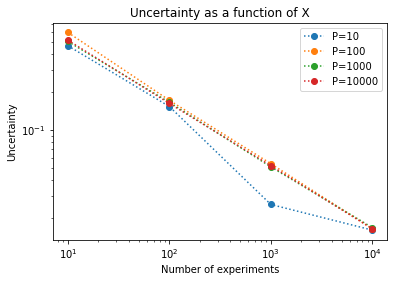

In [36]:
# log-log-plot with fixed number of pairs

plt.plot(experiments, pi_std_fixed_pairs[0], linestyle = ':', marker = 'o', label = 'P=10')
plt.plot(experiments, pi_std_fixed_pairs[1], linestyle = ':', marker = 'o', label = 'P=100')
plt.plot(experiments, pi_std_fixed_pairs[2], linestyle = ':', marker = 'o', label = 'P=1000')
plt.plot(experiments, pi_std_fixed_pairs[3], linestyle = ':', marker = 'o', label = 'P=10000')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of experiments')
plt.ylabel('Uncertainty')
plt.legend()
plt.title('Uncertainty as a function of X')
plt.show()

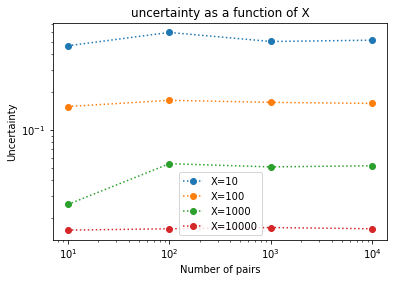

In [37]:
# log-log-plot with fixed number of experiments

plt.plot(pairs, pi_std_fixed_experiments[0], linestyle = ':', marker = 'o', label = 'X=10')
plt.plot(pairs, pi_std_fixed_experiments[1], linestyle = ':', marker = 'o', label = 'X=100')
plt.plot(pairs, pi_std_fixed_experiments[2], linestyle = ':', marker = 'o', label = 'X=1000')
plt.plot(pairs, pi_std_fixed_experiments[3], linestyle = ':', marker = 'o', label = 'X=10000')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of pairs')
plt.ylabel('Uncertainty')
plt.legend()
plt.title('uncertainty as a function of X')
plt.show()

With increasing number of pairs and fixed experiments the logharithm of the uncertainties is roughly constant, while it goes linearly down with fixed number of pairs and increasing experiments.